# 4 — Explainable AI (SHAP) & Phân khúc rủi ro

Notebook này thực hiện phần đầu: giải thích mô hình cuối cùng (CatBoost)
bằng SHAP (global + local explanation), rồi phân khúc rủi ro cho toàn bộ nhân sự.


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load mô hình cuối cùng & dữ liệu

SHAP's `TreeExplainer` cần model cây "thuần" — tách classifier ra khỏi bước SMOTE
trong Pipeline (`named_steps['clf']`).

In [2]:
final_pipeline = joblib.load("../models/final_model.pkl")
with open("../models/threshold.txt") as f:
    best_threshold = float(f.read())
with open("../models/model_name.txt") as f:
    model_name = f.read()

clf = final_pipeline.named_steps['clf']
print(f"Mô hình cuối: {model_name}  |  Ngưỡng: {best_threshold:.3f}")
print(f"Loại classifier: {type(clf).__name__}")

# Tái tạo dữ liệu (giống hệt Ngày 2/3)
df = pd.read_csv("../data/processed/attrition_encoded.csv")
X = df.drop(columns=['Attrition'])
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = joblib.load("../models/scaler.pkl")
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


Mô hình cuối: CatBoost (tuned)  |  Ngưỡng: 0.092
Loại classifier: CatBoostClassifier


## 2. Global Explanation — Beeswarm Plot

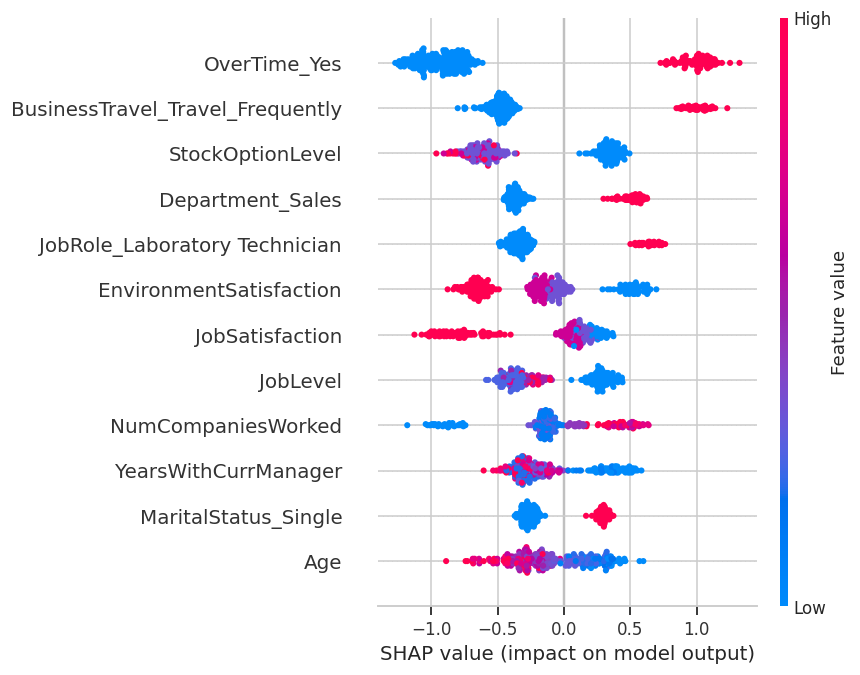

In [3]:
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_test_scaled)

# CatBoost nhị phân: shap_values có thể có shape (n, features, 2) — lấy lớp 1 (Yes) nếu vậy
if len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

# Giá trị SHAP được tính trên dữ liệu ĐÃ chuẩn hoá (đúng như model thật sự nhận vào),
# nhưng để hiển thị cho người không chuyên, gắn lại dữ liệu GỐC (chưa scale) — dễ đọc hơn
# nhiều so với z-score (VD: "JobSatisfaction = 4" thay vì "JobSatisfaction = 1.154").
shap_values_display = shap.Explanation(
    values=shap_values_class1.values,
    base_values=shap_values_class1.base_values,
    data=X_test.values,
    feature_names=X_test_scaled.columns.tolist(),
)

shap.summary_plot(shap_values_display, X_test, show=False, max_display=12)
plt.tight_layout()
plt.savefig("../images/10_shap_beeswarm.png", bbox_inches='tight')
plt.show()


In [4]:
# Bảng xếp hạng mức độ quan trọng toàn cục (mean |SHAP value|)
importance = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'mean_abs_shap': np.abs(shap_values_class1.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 10 biến quan trọng nhất theo SHAP:")
print(importance.head(10).to_string(index=False))


Top 10 biến quan trọng nhất theo SHAP:
                         feature  mean_abs_shap
                    OverTime_Yes       0.948871
BusinessTravel_Travel_Frequently       0.573040
                StockOptionLevel       0.502759
                Department_Sales       0.407295
   JobRole_Laboratory Technician       0.383417
         EnvironmentSatisfaction       0.375163
                 JobSatisfaction       0.342319
                        JobLevel       0.319560
              NumCompaniesWorked       0.293423
            YearsWithCurrManager       0.291866


### Diễn giải kết quả thật

Theo bảng xếp hạng SHAP ở trên, **`OverTime` (làm thêm giờ)** là yếu tố ảnh hưởng mạnh nhất
đến rủi ro nghỉ việc — bỏ xa yếu tố đứng thứ 2 (gần gấp đôi mức độ đóng góp). Đi làm thêm giờ
thường xuyên gần như luôn đẩy xác suất dự đoán nghỉ việc lên cao, bất kể các yếu tố khác.

**5 yếu tố hàng đầu và ý nghĩa kinh doanh:**
1. **OverTime = Yes** → rủi ro tăng mạnh nhất trong tất cả các biến.
2. **BusinessTravel = Travel_Frequently** → đi công tác thường xuyên cũng làm tăng rủi ro rõ rệt.
3. **StockOptionLevel thấp** → nhân viên có ít/không có cổ phần thưởng có xu hướng rời đi nhiều hơn.
4. **Department = Sales** và **JobRole = Laboratory Technician** → 2 nhóm có rủi ro nội tại
   cao hơn các phòng ban/vị trí khác, có thể do đặc thù công việc hoặc văn hoá nhóm.
5. **EnvironmentSatisfaction & JobSatisfaction thấp** → mức hài lòng thấp là tín hiệu cảnh báo
   sớm nhất quán, đúng như trực giác quản trị nhân sự thông thường.

**Góc nhìn kinh doanh cho HR:** ưu tiên rà soát chính sách làm thêm giờ và tần suất công tác ở
2 nhóm Sales/Lab Technician trước tiên — đây là đòn bẩy có khả năng giảm rủi ro nghỉ việc rõ
rệt nhất, thay vì tăng lương đồng loạt (MonthlyIncome không nằm trong top 10 yếu tố SHAP).

## 3. Local Explanation — Waterfall Plot cho 1 nhân viên cụ thể

Chọn nhân viên tại vị trí test #92 — xác suất nghỉ việc dự đoán: 98.8%, thực tế: Có nghỉ


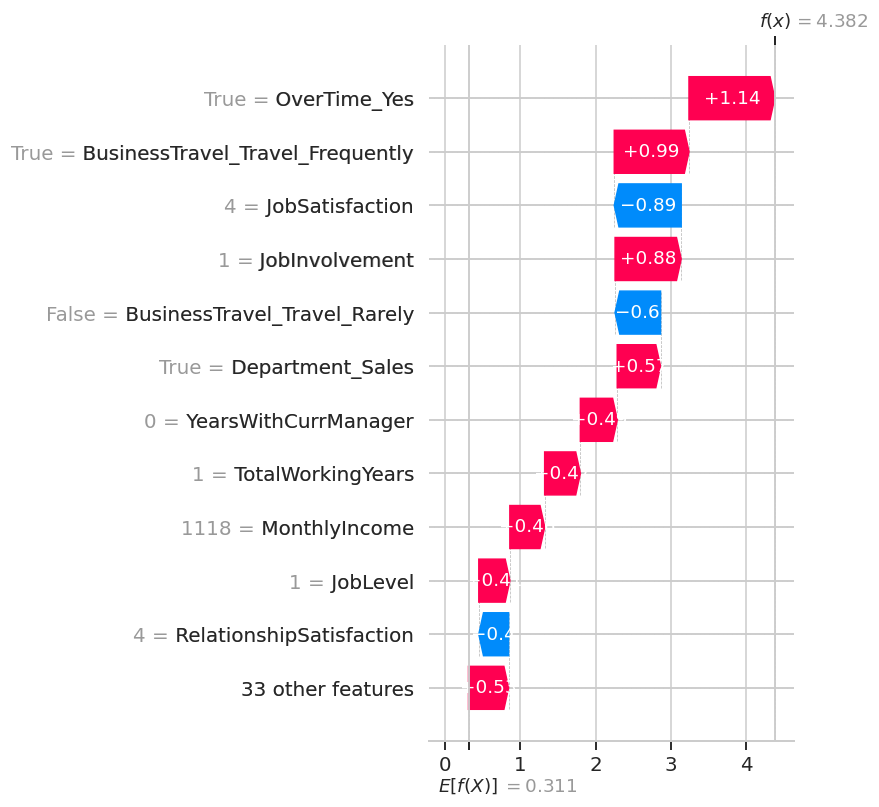

In [5]:
proba_test = clf.predict_proba(X_test_scaled)[:, 1]

# Chọn 1 ca "True Positive" có xác suất cao nhất — mô hình đúng VÀ tự tin
tp_mask = (proba_test >= best_threshold) & (y_test.values == 1)
if tp_mask.sum() > 0:
    tp_indices = np.where(tp_mask)[0]
    local_idx = tp_indices[np.argmax(proba_test[tp_indices])]
else:
    local_idx = int(np.argmax(proba_test))

print(f"Chọn nhân viên tại vị trí test #{local_idx} — "
      f"xác suất nghỉ việc dự đoán: {proba_test[local_idx]:.1%}, "
      f"thực tế: {'Có nghỉ' if y_test.values[local_idx]==1 else 'Không nghỉ'}")

shap.plots.waterfall(shap_values_display[local_idx], show=False, max_display=12)
plt.tight_layout()
plt.savefig("../images/11_shap_waterfall_example.png", bbox_inches='tight')
plt.show()


### Phân tích hồ sơ rủi ro cá nhân (Waterfall Plot)

Biểu đồ Waterfall giúp nhân sự (HR) nhìn thấu quá trình cộng dồn rủi ro dẫn đến quyết định nghỉ việc của một cá nhân cụ thể. 

**đọc biểu đồ:**
*   **Trục dọc:** Hiển thị các đặc điểm cụ thể của nhân viên này (Ví dụ: Tuổi = 32, Làm thêm giờ = Có).
*   **E[f(x)] ở đáy:** Là điểm xuất phát (xác suất nghỉ việc trung bình của toàn công ty).
*   **f(x) ở đỉnh:** Là xác suất nghỉ việc cuối cùng của riêng nhân viên này (Ví dụ: 98.8%).
*   **Thanh màu Đỏ (Mũi tên hướng phải):** Những yếu tố cộng dồn làm **tăng** ý định nghỉ việc. Thanh càng dài, lực đẩy càng mạnh.
*   **Thanh màu Xanh lam (Mũi tên hướng trái):** Những yếu tố đang níu kéo, giúp **giảm** rủi ro nghỉ việc. 

**Rút ra:** Nhìn vào biểu đồ của một nhân viên đang nằm trong nhóm "Rủi ro Cao", HR có thể biết ngay đâu là "nỗi đau" lớn nhất của họ (những thanh màu đỏ dài nhất) để đưa ra lời đề nghị giữ chân (retention offer) trúng đích nhất, thay vì đoán mò.

## 4. Phân khúc rủi ro cho toàn bộ nhân sự (1.470 người)

In [6]:
X_full_scaled = X.copy()
X_full_scaled[numeric_cols] = scaler.transform(X[numeric_cols])

proba_full = clf.predict_proba(X_full_scaled)[:, 1]

risk_df = df[['Attrition']].copy()
risk_df['Risk_Score'] = proba_full
risk_df['Risk_Level'] = pd.cut(
    proba_full,
    bins=[0, best_threshold / 3, best_threshold, 1],
    labels=['Thấp', 'Trung bình', 'Cao'],
)

print(risk_df['Risk_Level'].value_counts())
print(f"\nNgưỡng dùng để phân khúc: Cao >= {best_threshold:.3f}, "
      f"Trung bình >= {best_threshold/3:.3f}")

risk_df.to_csv("../data/processed/risk_segmentation.csv", index=False)
print("\nĐã lưu risk_segmentation.csv")


Risk_Level
Thấp          634
Cao           421
Trung bình    415
Name: count, dtype: int64

Ngưỡng dùng để phân khúc: Cao >= 0.092, Trung bình >= 0.031

Đã lưu risk_segmentation.csv


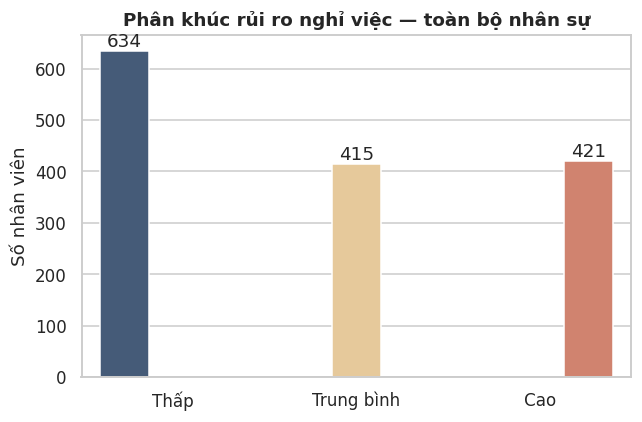

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ['Thấp', 'Trung bình', 'Cao']
colors = ['#3d5a80', '#f2cc8f', '#e07a5f']
sns.countplot(data=risk_df, x='Risk_Level', hue='Risk_Level', order=order,
              palette=colors, legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Phân khúc rủi ro nghỉ việc — toàn bộ nhân sự")
ax.set_xlabel(""); ax.set_ylabel("Số nhân viên")
plt.tight_layout()
plt.savefig("../images/12_risk_segmentation.png", bbox_inches='tight')
plt.show()


## Tổng kết notebooks 4 (phần SHAP & phân khúc rủi ro)

- SHAP TreeExplainer tích hợp thành công, có cả beeswarm (global) và waterfall (local)
- Đã xác định top 10 biến quan trọng nhất theo mức độ đóng góp SHAP
- Toàn bộ 1.470 nhân sự đã được phân khúc Thấp/Trung bình/Cao, lưu ra CSV

**Bước tiếp theo:** Streamlit dashboard + đóng gói GitHub.
